# Notebook 2 - Exploratory Data Analysis (EDA)

**Project phase:** Formula 1 Big Data Analysis with PySpark  
**Spark components:** PySpark DataFrame API, SparkSQL  
**Goal:** Explore historical Formula 1 data using the PySpark DataFrame API, perform exploratory data analysis with visualizations, and create driver career flow diagrams to investigate team transitions, career trajectories, and performance trends across seasons.

## 1. Spark session & gold tables

In [15]:
from pyspark.sql import SparkSession, Window
from pyspark.sql import functions as F
from google.colab import drive
import os

drive.mount('/content/drive')

spark = (
    SparkSession.builder
    .appName("F1 Notebook 2b - EDA")
    .config("spark.jars.packages", "graphframes:graphframes:0.8.3-spark3.5-s_2.12")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")

DATASET_PATH = "/content/drive/MyDrive/data_analysis"
SILVER_PATH = f"{DATASET_PATH}/lakehouse/silver"
GOLD_PATH = f"{DATASET_PATH}/lakehouse/gold"

!wget -q https://raw.githubusercontent.com/simon-sazonov/BigDataAnalytics/main/helpers.py -O helpers.py
from helpers import describe_cluster, cluster_team_summary, cluster_bar, cluster_heatmap

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# !apt-get install -y graphviz

In [16]:
silver = {}

for table_name in os.listdir(SILVER_PATH):
    table_path = f"{SILVER_PATH}/{table_name}"

    if os.path.isdir(table_path):
        silver[table_name] = spark.read.parquet(table_path)

## General overview of all tables
*   number of rows
*   number of columns
*   data types
*   example records

In [ ]:
for name, df in silver.items():
    print(f"\n{name}")
    print(f"Rows: {df.count()}")
    print(f"Columns: {len(df.columns)}")
    df.printSchema()


races
Rows: 1125
Columns: 8
root
 |-- raceId: integer (nullable = true)
 |-- round: integer (nullable = true)
 |-- circuitId: integer (nullable = true)
 |-- race_name: string (nullable = true)
 |-- date: date (nullable = true)
 |-- ingested_at: timestamp (nullable = true)
 |-- source_file: string (nullable = true)
 |-- year: integer (nullable = true)


drivers
Rows: 861
Columns: 12
root
 |-- driverId: integer (nullable = true)
 |-- driverRef: string (nullable = true)
 |-- number: integer (nullable = true)
 |-- code: string (nullable = true)
 |-- forename: string (nullable = true)
 |-- surname: string (nullable = true)
 |-- dob: date (nullable = true)
 |-- nationality: string (nullable = true)
 |-- url: string (nullable = true)
 |-- ingested_at: timestamp (nullable = true)
 |-- source_file: string (nullable = true)
 |-- driver_name: string (nullable = true)


constructors
Rows: 212
Columns: 7
root
 |-- constructorId: integer (nullable = true)
 |-- constructorRef: string (nullable = tru

In [ ]:
for name, df in silver.items():
    print(f"\n{name}")
    df.show(5)


races
+------+-----+---------+--------------------+----------+--------------------+-----------+----+
|raceId|round|circuitId|           race_name|      date|         ingested_at|source_file|year|
+------+-----+---------+--------------------+----------+--------------------+-----------+----+
|  1121|    1|        3|  Bahrain Grand Prix|2024-03-02|2026-05-29 20:12:...|  races.csv|2024|
|  1122|    2|       77|Saudi Arabian Gra...|2024-03-09|2026-05-29 20:12:...|  races.csv|2024|
|  1123|    3|        1|Australian Grand ...|2024-03-24|2026-05-29 20:12:...|  races.csv|2024|
|  1124|    4|       22| Japanese Grand Prix|2024-04-07|2026-05-29 20:12:...|  races.csv|2024|
|  1125|    5|       17|  Chinese Grand Prix|2024-04-21|2026-05-29 20:12:...|  races.csv|2024|
+------+-----+---------+--------------------+----------+--------------------+-----------+----+
only showing top 5 rows

drivers
+--------+----------+------+----+--------+----------+----------+-----------+--------------------+--------

### Structural and Logical Data Validation

Before going deeper into the analysis, we check the quality of the data.

We look for:
- duplicate primary keys,
- broken links between tables (foreign keys),
- impossible numeric values,
- invalid map coordinates,
- and other logical errors.

All checks use PySpark aggregations and joins, so they also work well on large datasets.

In [ ]:
from pyspark.sql import functions as F

# ============================================================
# Assign tables from silver layer
# ============================================================

races = silver["races"]
drivers = silver["drivers"]
constructors = silver["constructors"]
circuits = silver["circuits"]
status = silver["status"]

results = silver["results"]
qualifying = silver["qualifying"]
lap_times = silver["lap_times"]
pit_stops = silver["pit_stops"]

driver_standings = silver["driver_standings"]
constructor_standings = silver["constructor_standings"]
constructor_results = silver["constructor_results"]

if "sprint_results" in silver:
    sprint_results = silver["sprint_results"]

# ============================================================
# Scalable Data Validation Helpers
# ============================================================

def show_duplicate_keys(df, key_cols, table_name):
    print(f"\nDuplicate key check: {table_name}")

    duplicates = (
        df.groupBy(*key_cols)
          .agg(F.count("*").alias("record_count"))
          .filter(F.col("record_count") > 1)
    )

    duplicates.show(20, truncate=False)


def show_invalid_value_summary(df, conditions, table_name):
    print(f"\nInvalid value summary: {table_name}")

    summary = df.agg(*[
        F.sum(F.when(condition, 1).otherwise(0)).alias(check_name)
        for check_name, condition in conditions.items()
    ])

    summary.show(truncate=False)


def show_foreign_key_violations(child_df, parent_df, child_key, parent_key, child_name, parent_name):
    print(f"\nForeign key check: {child_name}.{child_key} -> {parent_name}.{parent_key}")

    missing_refs = (
        child_df.select(child_key).distinct()
        .join(
            parent_df.select(parent_key).distinct(),
            child_df[child_key] == parent_df[parent_key],
            "left_anti"
        )
    )

    missing_refs.show(20, truncate=False)


# ============================================================
# 1. Duplicate Key Checks
# ============================================================

show_duplicate_keys(races, ["raceId"], "races")
show_duplicate_keys(drivers, ["driverId"], "drivers")
show_duplicate_keys(constructors, ["constructorId"], "constructors")
show_duplicate_keys(circuits, ["circuitId"], "circuits")
show_duplicate_keys(status, ["statusId"], "status")

show_duplicate_keys(results, ["resultId"], "results")
show_duplicate_keys(qualifying, ["qualifyId"], "qualifying")
show_duplicate_keys(driver_standings, ["driverStandingsId"], "driver_standings")
show_duplicate_keys(constructor_standings, ["constructorStandingsId"], "constructor_standings")
show_duplicate_keys(constructor_results, ["constructorResultsId"], "constructor_results")

if "sprint_results" in globals():
    show_duplicate_keys(sprint_results, ["resultId"], "sprint_results")


# ============================================================
# 2. Foreign Key Integrity Checks
# ============================================================

show_foreign_key_violations(results, races, "raceId", "raceId", "results", "races")
show_foreign_key_violations(results, drivers, "driverId", "driverId", "results", "drivers")
show_foreign_key_violations(results, constructors, "constructorId", "constructorId", "results", "constructors")
show_foreign_key_violations(results, status, "statusId", "statusId", "results", "status")

show_foreign_key_violations(races, circuits, "circuitId", "circuitId", "races", "circuits")

show_foreign_key_violations(qualifying, races, "raceId", "raceId", "qualifying", "races")
show_foreign_key_violations(qualifying, drivers, "driverId", "driverId", "qualifying", "drivers")
show_foreign_key_violations(qualifying, constructors, "constructorId", "constructorId", "qualifying", "constructors")

show_foreign_key_violations(driver_standings, races, "raceId", "raceId", "driver_standings", "races")
show_foreign_key_violations(driver_standings, drivers, "driverId", "driverId", "driver_standings", "drivers")

show_foreign_key_violations(constructor_standings, races, "raceId", "raceId", "constructor_standings", "races")
show_foreign_key_violations(constructor_standings, constructors, "constructorId", "constructorId", "constructor_standings", "constructors")

show_foreign_key_violations(constructor_results, races, "raceId", "raceId", "constructor_results", "races")
show_foreign_key_violations(constructor_results, constructors, "constructorId", "constructorId", "constructor_results", "constructors")

if "sprint_results" in globals():
    show_foreign_key_violations(sprint_results, races, "raceId", "raceId", "sprint_results", "races")
    show_foreign_key_violations(sprint_results, drivers, "driverId", "driverId", "sprint_results", "drivers")
    show_foreign_key_violations(sprint_results, constructors, "constructorId", "constructorId", "sprint_results", "constructors")
    show_foreign_key_violations(sprint_results, status, "statusId", "statusId", "sprint_results", "status")


# ============================================================
# 3. Range and Logical Consistency Checks
# ============================================================

show_invalid_value_summary(
    races,
    {
        "year_before_1950": F.col("year") < 1950,
        "round_less_than_1": F.col("round") < 1,
        "missing_date": F.col("date").isNull()
    },
    "races"
)

show_invalid_value_summary(
    circuits,
    {
        "invalid_latitude": (F.col("lat") < -90) | (F.col("lat") > 90),
        "invalid_longitude": (F.col("lng") < -180) | (F.col("lng") > 180),
        "missing_latitude": F.col("lat").isNull(),
        "missing_longitude": F.col("lng").isNull()
    },
    "circuits"
)

show_invalid_value_summary(
    results,
    {
        "negative_grid": F.col("grid") < 0,
        "negative_position_order": F.col("positionOrder") < 0,
        "negative_points": F.col("points") < 0,
        "negative_laps": F.col("laps") < 0,
        "negative_milliseconds": F.col("milliseconds") < 0,
        "negative_fastest_lap_speed": F.col("fastestLapSpeed") < 0,
        "zero_fastest_lap_speed": F.col("fastestLapSpeed") == 0,
        "fastest_lap_greater_than_laps": F.col("fastestLap") > F.col("laps")
    },
    "results"
)

show_invalid_value_summary(
    qualifying,
    {
        "position_less_than_1": F.col("position") < 1,
        "negative_q1_ms": F.col("q1_ms") < 0,
        "negative_q2_ms": F.col("q2_ms") < 0,
        "negative_q3_ms": F.col("q3_ms") < 0,
        "negative_best_qualifying_ms": F.col("best_qualifying_ms") < 0
    },
    "qualifying"
)

show_invalid_value_summary(
    lap_times,
    {
        "lap_less_than_1": F.col("lap") < 1,
        "position_less_than_1": F.col("position") < 1,
        "negative_milliseconds": F.col("milliseconds") < 0,
        "negative_lap_time_ms": F.col("lap_time_ms") < 0
    },
    "lap_times"
)

show_invalid_value_summary(
    pit_stops,
    {
        "stop_less_than_1": F.col("stop") < 1,
        "lap_less_than_1": F.col("lap") < 1,
        "negative_pit_stop_ms": F.col("pit_stop_ms") < 0
    },
    "pit_stops"
)

show_invalid_value_summary(
    driver_standings,
    {
        "negative_points": F.col("points") < 0,
        "position_less_than_1": F.col("position") < 1,
        "negative_wins": F.col("wins") < 0
    },
    "driver_standings"
)

show_invalid_value_summary(
    constructor_standings,
    {
        "negative_points": F.col("points") < 0,
        "position_less_than_1": F.col("position") < 1,
        "negative_wins": F.col("wins") < 0
    },
    "constructor_standings"
)

show_invalid_value_summary(
    constructor_results,
    {
        "negative_points": F.col("points") < 0
    },
    "constructor_results"
)

if "sprint_results" in globals():
    show_invalid_value_summary(
        sprint_results,
        {
            "negative_grid": F.col("grid") < 0,
            "negative_position_order": F.col("positionOrder") < 0,
            "negative_points": F.col("points") < 0,
            "negative_laps": F.col("laps") < 0,
            "negative_milliseconds": F.col("milliseconds") < 0,
            "fastest_lap_greater_than_laps": F.col("fastestLap") > F.col("laps")
        },
        "sprint_results"
    )


Duplicate key check: races
+------+------------+
|raceId|record_count|
+------+------------+
+------+------------+


Duplicate key check: drivers
+--------+------------+
|driverId|record_count|
+--------+------------+
+--------+------------+


Duplicate key check: constructors
+-------------+------------+
|constructorId|record_count|
+-------------+------------+
+-------------+------------+


Duplicate key check: circuits
+---------+------------+
|circuitId|record_count|
+---------+------------+
+---------+------------+


Duplicate key check: status
+--------+------------+
|statusId|record_count|
+--------+------------+
+--------+------------+


Duplicate key check: results
+--------+------------+
|resultId|record_count|
+--------+------------+
+--------+------------+


Duplicate key check: qualifying
+---------+------------+
|qualifyId|record_count|
+---------+------------+
+---------+------------+


Duplicate key check: driver_standings
+-----------------+------------+
|driverStandi

### Validation Results

The checks show that the data is in good shape.

There are no duplicate primary keys, so every record has a unique identifier. There are also no broken links between tables, so the relationships between tables stay consistent.

The range and logic checks find no negative values, impossible numbers, or invalid map coordinates. The only small issue is in the `results` table, where a few records have a `fastestLap` value larger than the number of completed laps. These are old data-recording errors and affect only a tiny part of the dataset.

Overall, the data is reliable and ready for the next steps.

## Missing Values Analysis

In [ ]:
for name, df in silver.items():
    print(f"\nMissing values in {name}")

    missing = df.select([
        F.count(F.when(F.col(c).isNull(), c)).alias(c)
        for c in df.columns
    ])

    missing.show(truncate=False)


Missing values in races
+------+-----+---------+---------+----+-----------+-----------+----+
|raceId|round|circuitId|race_name|date|ingested_at|source_file|year|
+------+-----+---------+---------+----+-----------+-----------+----+
|0     |0    |0        |0        |0   |0          |0          |0   |
+------+-----+---------+---------+----+-----------+-----------+----+


Missing values in drivers
+--------+---------+------+----+--------+-------+---+-----------+---+-----------+-----------+-----------+
|driverId|driverRef|number|code|forename|surname|dob|nationality|url|ingested_at|source_file|driver_name|
+--------+---------+------+----+--------+-------+---+-----------+---+-----------+-----------+-----------+
|0       |0        |802   |757 |0       |0      |0  |0          |0  |0          |0          |0          |
+--------+---------+------+----+--------+-------+---+-----------+---+-----------+-----------+-----------+


Missing values in constructors
+-------------+--------------+---------

In [ ]:
constructor_results = silver["constructor_results"]
sprint_results = silver["sprint_results"]

race_linked_tables_with_missing_values = {
    "results": results,
    "qualifying": qualifying,
    "constructor_results": constructor_results,
    "sprint_results": sprint_results
}

def add_era(df):
    return df.withColumn(
        "era",
        F.when(F.col("race_year") < 2004, "1950-2003")
         .when(F.col("race_year") < 2006, "2004-2005")
         .when(F.col("race_year") < 2020, "2006-2019")
         .otherwise("2020+")
    )

races_year = races.select(
    "raceId",
    F.col("year").alias("race_year")
)

for table_name, df in race_linked_tables_with_missing_values.items():
    print(f"\nMissing values by era: {table_name}")

    df_year = df.join(
        races_year,
        on="raceId",
        how="left"
    )

    df_year = add_era(df_year)

    missing_cols = [
        c for c in df.columns
        if df.filter(F.col(c).isNull()).limit(1).count() > 0
    ]

    summary = df_year.groupBy("era").agg(
        F.count("*").alias("total_records"),
        *[
            F.sum(F.when(F.col(c).isNull(), 1).otherwise(0)).alias(f"missing_{c}")
            for c in missing_cols
        ]
    )

    summary.orderBy("era").show(truncate=False)


Missing values by era: results
+---------+-------------+--------------+------------+--------------------+------------------+------------+----------------------+-----------------------+------------------------+----------------------+
|era      |total_records|missing_number|missing_time|missing_milliseconds|missing_fastestLap|missing_rank|missing_fastestLapTime|missing_fastestLapSpeed|missing_race_duration_ms|missing_fastest_lap_ms|
+---------+-------------+--------------+------------+--------------------+------------------+------------+----------------------+-----------------------+------------------------+----------------------+
|1950-2003|18109        |6             |14727       |14727               |18109             |18109       |18109                 |18109                  |14727                   |18109                 |
|2004-2005|736          |0             |448         |448                 |35                |35          |35                    |35                     |448    

In [ ]:
drivers_missing = drivers.select([
    F.sum(F.when(F.col(c).isNull(), 1).otherwise(0)).alias(f"missing_{c}")
    for c in drivers.columns
])

drivers_missing.show(truncate=False)

+----------------+-----------------+--------------+------------+----------------+---------------+-----------+-------------------+-----------+-------------------+-------------------+-------------------+
|missing_driverId|missing_driverRef|missing_number|missing_code|missing_forename|missing_surname|missing_dob|missing_nationality|missing_url|missing_ingested_at|missing_source_file|missing_driver_name|
+----------------+-----------------+--------------+------------+----------------+---------------+-----------+-------------------+-----------+-------------------+-------------------+-------------------+
|0               |0                |802           |757         |0               |0              |0          |0                  |0          |0                  |0                  |0                  |
+----------------+-----------------+--------------+------------+----------------+---------------+-----------+-------------------+-----------+-------------------+-------------------+-----------

### Missing-Value Findings and Recommendations

This section summarizes what the missing-value analysis above shows, and gives recommendations for how each table should be handled. These are recommendations only. No column is changed or removed here — the actual preprocessing is applied later, in the Gold Layer Construction step.

#### Drivers table

The `number` and `code` columns are often empty. This is expected: permanent driver numbers and modern FIA driver codes were only introduced in recent seasons. These columns add little analytical value and are inconsistent across eras.

Recommendation: exclude `number` and `code` from later analysis.

#### Results table

Many timing columns are mostly empty before 2004, because early seasons did not have reliable electronic timing.

Total race times (`time`, `milliseconds`, `race_duration_ms`) cannot be compared fairly between drivers, because retired and lapped cars finish with very different times. `fastest_lap_ms` and `fastestLapTime` both describe the same fastest lap; `fastestLapTime` is only a text value like "1:27.452", while `fastestLapSpeed` already captures fastest-lap performance as a clean number.

Recommendation: exclude `time`, `milliseconds`, `race_duration_ms`, `fastest_lap_ms`, and `fastestLapTime`.

The columns `fastestLap`, `rank`, and `fastestLapSpeed` are numeric and mostly complete from 2004 onwards. They still have some empty values, but an empty value here is not an error: it means the driver set no recorded fastest lap, usually because of an early retirement.

Recommendation: keep `fastestLap`, `rank`, and `fastestLapSpeed`. Keep their empty values as they are and handle them later, during modeling.

#### Qualifying table

Qualifying columns are hard to compare across seasons, because the qualifying format changed several times. Not every driver reaches Q2 and Q3, and the millisecond columns are often empty.

Recommendation: do not use qualifying data in the final tables.

#### Constructor results table

The `status` column is almost completely empty in every season, so this table carries almost no usable information.

Recommendation: do not include the constructor results table in the final tables.

#### Sprint results table

Sprint races are quite complete and have only a few empty values. The same reasoning as for the results table applies to its raw timing columns. Sprint races only exist in recent seasons, so this table cannot be used for long-term historical analysis.

Recommendation: exclude the raw timing columns (`time`, `milliseconds`, `fastestLapTime`), and fill the `position` column from `positionOrder` for drivers who did not finish.

#### Recommended missing-value strategy

To summarize:
- Columns that are mostly empty before 2004, or inconsistent across eras, should be excluded.
- The final tables should keep only races from 2004 onwards, where the data is reliable.
- Remaining empty values (early retirements, no recorded fastest lap) are real information, not errors. They should be kept and handled during modeling — not by changing the stored tables.


## Seasons and Historical Coverage

In [ ]:
yearly_races = races.groupBy("year") \
    .agg(F.countDistinct("raceId").alias("num_races")) \
    .orderBy("year")

yearly_races.show(100)

+----+---------+
|year|num_races|
+----+---------+
|1950|        7|
|1951|        8|
|1952|        8|
|1953|        9|
|1954|        9|
|1955|        7|
|1956|        8|
|1957|        8|
|1958|       11|
|1959|        9|
|1960|       10|
|1961|        8|
|1962|        9|
|1963|       10|
|1964|       10|
|1965|       10|
|1966|        9|
|1967|       11|
|1968|       12|
|1969|       11|
|1970|       13|
|1971|       11|
|1972|       12|
|1973|       15|
|1974|       15|
|1975|       14|
|1976|       16|
|1977|       17|
|1978|       16|
|1979|       15|
|1980|       14|
|1981|       15|
|1982|       16|
|1983|       15|
|1984|       16|
|1985|       16|
|1986|       16|
|1987|       16|
|1988|       16|
|1989|       16|
|1990|       16|
|1991|       16|
|1992|       16|
|1993|       16|
|1994|       16|
|1995|       17|
|1996|       16|
|1997|       17|
|1998|       16|
|1999|       16|
|2000|       17|
|2001|       17|
|2002|       17|
|2003|       16|
|2004|       18|
|2005|       1

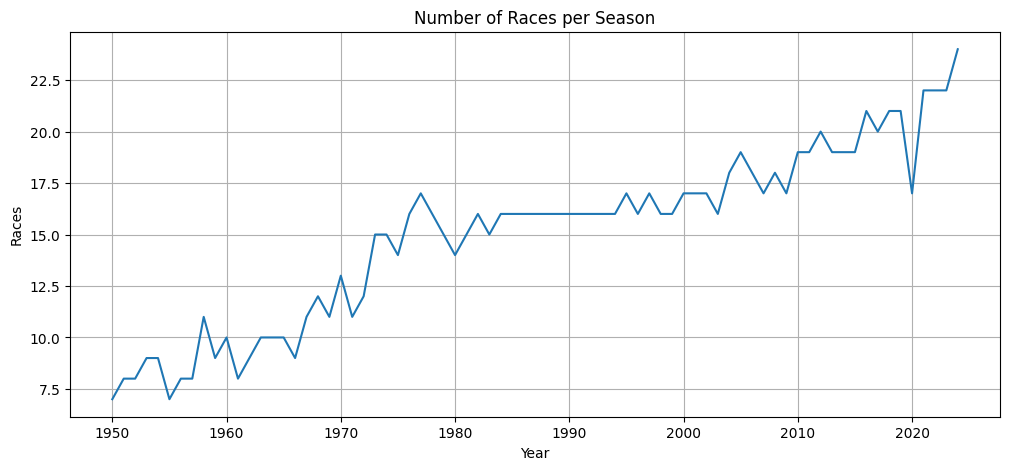

In [ ]:
pdf = yearly_races.toPandas()

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(pdf["year"], pdf["num_races"])
plt.title("Number of Races per Season")
plt.xlabel("Year")
plt.ylabel("Races")
plt.grid(True)
plt.show()

## Driver Performance Analysis

### Top drivers by wins

In [ ]:
fact_race_result = spark.read.parquet(f"{GOLD_PATH}/fact_race_result")
top_winners = fact_race_result.filter(F.col("position") == 1) \
    .groupBy("driverId") \
    .agg(F.countDistinct("raceId").alias("wins")) \
    .join(
        drivers.select("driverId", "driver_name"),
        on="driverId",
        how="left"
    ) \
    .select("driver_name", "wins") \
    .orderBy(F.desc("wins"))

top_winners.show(20, truncate=False)

+------------------+----+
|driver_name       |wins|
+------------------+----+
|Lewis Hamilton    |105 |
|Michael Schumacher|91  |
|Max Verstappen    |63  |
|Sebastian Vettel  |53  |
|Alain Prost       |51  |
|Ayrton Senna      |41  |
|Fernando Alonso   |32  |
|Nigel Mansell     |31  |
|Jackie Stewart    |27  |
|Niki Lauda        |25  |
|Jim Clark         |25  |
|Juan Fangio       |24  |
|Nico Rosberg      |23  |
|Nelson Piquet     |23  |
|Damon Hill        |22  |
|Kimi Räikkönen    |21  |
|Mika Häkkinen     |20  |
|Stirling Moss     |16  |
|Jenson Button     |15  |
|Emerson Fittipaldi|14  |
+------------------+----+
only showing top 20 rows


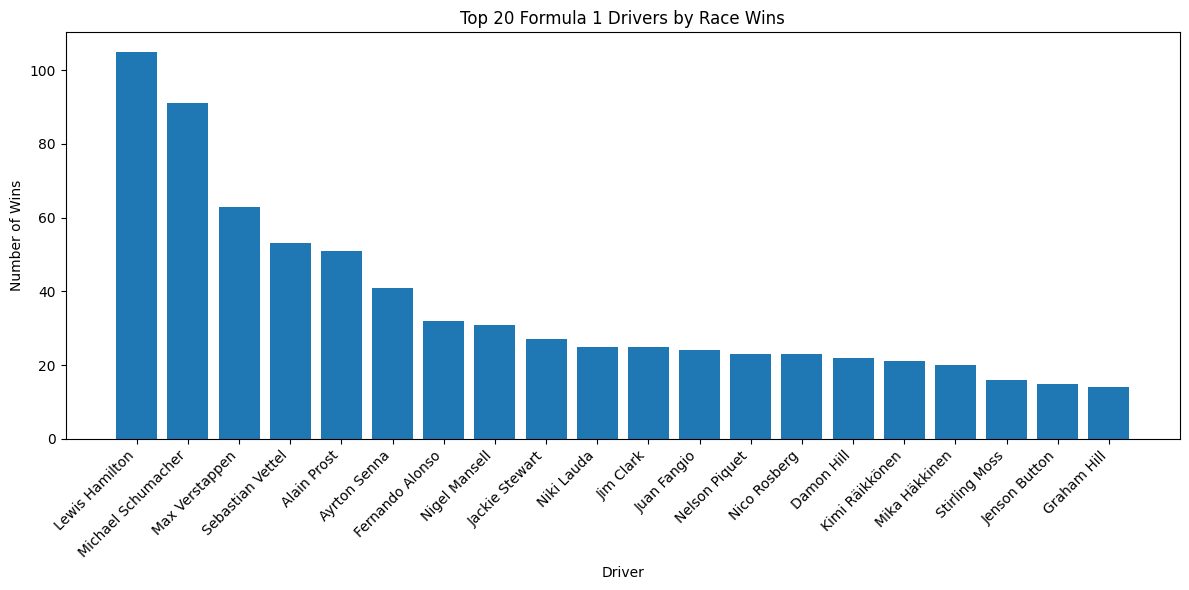

In [ ]:
top_winners_pd = top_winners.limit(20).toPandas()

plt.figure(figsize=(12, 6))
plt.bar(top_winners_pd["driver_name"], top_winners_pd["wins"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("Driver")
plt.ylabel("Number of Wins")
plt.title("Top 20 Formula 1 Drivers by Race Wins")
plt.tight_layout()
plt.show()

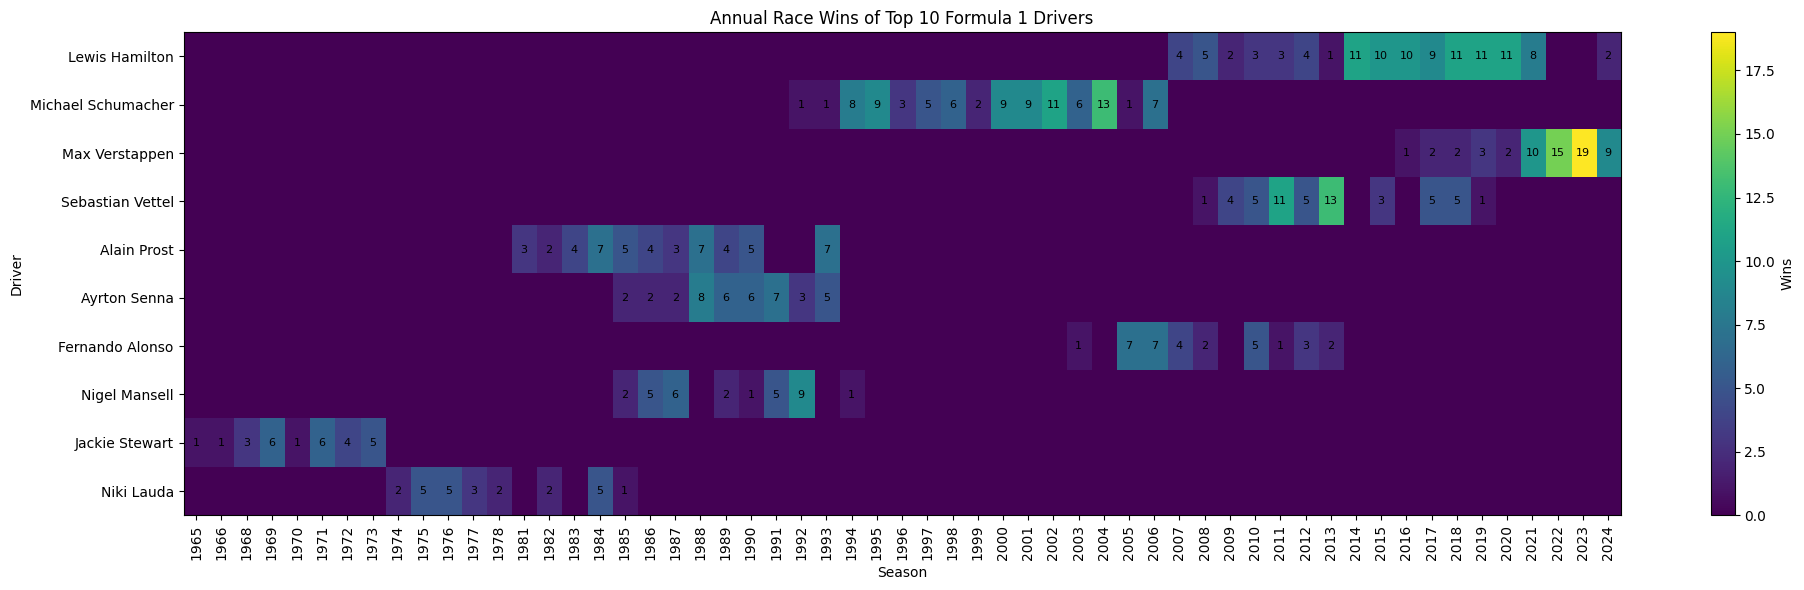

In [ ]:
# Top 10 drivers by total wins
top10_drivers = fact_race_result \
    .filter(F.col("position") == 1) \
    .groupBy("driverId") \
    .agg(F.countDistinct("raceId").alias("total_wins")) \
    .orderBy(F.desc("total_wins")) \
    .limit(10)

# Annual wins for those drivers
yearly_wins = fact_race_result \
    .filter(F.col("position") == 1) \
    .join(top10_drivers.select("driverId"), on="driverId") \
    .groupBy("year", "driverId") \
    .agg(F.countDistinct("raceId").alias("wins"))

# Add driver names
yearly_wins_named = yearly_wins.join(
    drivers.select("driverId", "driver_name"),
    on="driverId",
    how="left"
)

# Convert to Pandas
wins_pd = yearly_wins_named.toPandas()

# Pivot for heatmap
heatmap_data = wins_pd.pivot_table(
    index="driver_name",
    columns="year",
    values="wins",
    fill_value=0
)

# Sort drivers by total wins
heatmap_data = heatmap_data.loc[
    heatmap_data.sum(axis=1).sort_values(ascending=False).index
]

plt.figure(figsize=(20, 6))

im = plt.imshow(
    heatmap_data,
    aspect="auto"
)

plt.colorbar(label="Wins")

# Add numbers inside cells
for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        value = heatmap_data.iloc[i, j]

        if value > 0:
            plt.text(
                j,
                i,
                int(value),
                ha="center",
                va="center",
                fontsize=8
            )

plt.yticks(
    range(len(heatmap_data.index)),
    heatmap_data.index
)

plt.xticks(
    range(len(heatmap_data.columns)),
    heatmap_data.columns,
    rotation=90
)

plt.xlabel("Season")
plt.ylabel("Driver")
plt.title("Annual Race Wins of Top 10 Formula 1 Drivers")

plt.tight_layout()
plt.show()

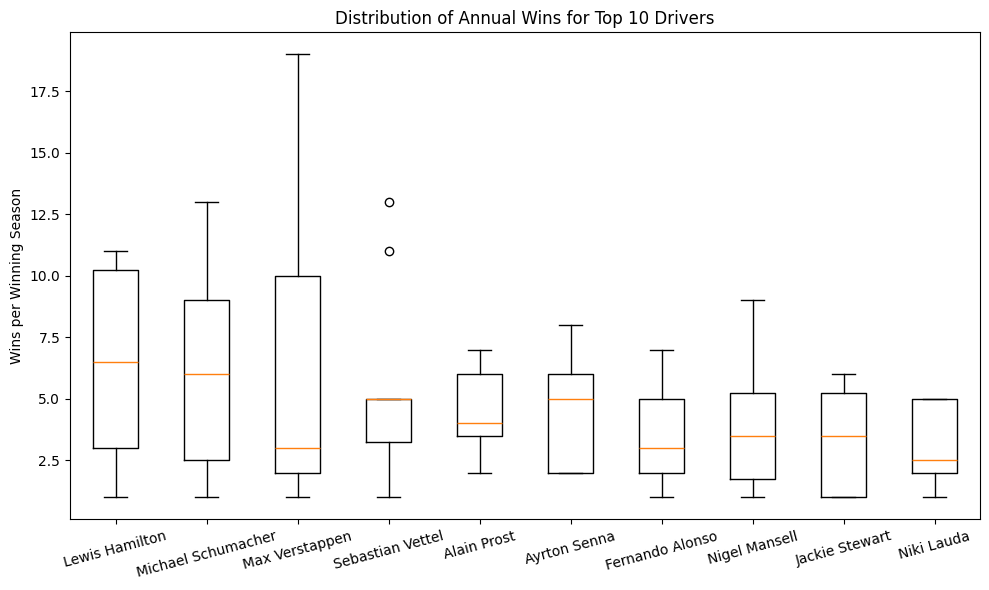

In [ ]:
# Convert to pandas
wins_pd = yearly_wins_named.toPandas()

# Prepare data for boxplot
driver_order = wins_pd.groupby("driver_name")["wins"] \
    .sum() \
    .sort_values(ascending=False) \
    .index

boxplot_data = [
    wins_pd[wins_pd["driver_name"] == driver]["wins"]
    for driver in driver_order
]

# Plot
plt.figure(figsize=(10, 6))

plt.boxplot(
    boxplot_data,
    tick_labels=driver_order
)

plt.ylabel("Wins per Winning Season")
plt.title("Distribution of Annual Wins for Top 10 Drivers")

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

### Distribution of Annual Wins for Top Drivers

The boxplot compares the distribution of annual race wins among the most successful Formula 1 drivers. Only seasons in which drivers achieved at least one victory were included in the analysis, allowing the comparison to focus on competitive performance rather than career length.

Several important patterns can be observed:

- **Lewis Hamilton** and **Michael Schumacher** demonstrate the highest median number of wins per successful season, indicating long-term consistency and sustained dominance across multiple years.

- **Max Verstappen** shows the largest variability in annual wins, with a very high maximum value reaching 19 wins in a single season. This reflects the exceptional level of dominance achieved during recent Red Bull seasons.

- **Sebastian Vettel** has a relatively compact distribution with several high outliers, suggesting strong peak performance concentrated in specific dominant years.

- **Ayrton Senna**, **Alain Prost**, **Fernando Alonso**, and **Nigel Mansell** exhibit more moderate distributions, reflecting strong performance with fewer exceptionally dominant seasons.

- Older-era drivers such as **Jim Clark** and **Jackie Stewart** generally have lower annual win totals. This is expected because earlier Formula 1 seasons contained significantly fewer races.

Overall, the visualizations highlight both the evolution of Formula 1 across decades and the differences in driver dominance, consistency, and peak performance.

## Business Questions (SparkSQL)

The following section answers eight business questions about Formula 1 using
**SparkSQL** (`spark.sql(...)`) against the gold lakehouse layer. All source
tables are registered as temporary views, every query is expressed in SQL, and
several queries use window functions (`RANK()`, `ROW_NUMBER()`, `AVG() OVER`).
Results are converted to Pandas **only after aggregation** and visualised with
`matplotlib`.

**Engine-era definition used throughout**

| Era label | Seasons |
|-----------|---------|
| `V10/V12 (<=2005)` | up to 2005 |
| `V8 (2006-2013)`   | 2006-2013 |
| `Hybrid (2014+)`   | 2014 onward |


In [3]:
# ============================================================
# Register gold + silver tables as SparkSQL temp views
# ============================================================
import matplotlib.pyplot as plt

fact_race_result = spark.read.parquet(f"{GOLD_PATH}/fact_race_result")
dim_driver       = spark.read.parquet(f"{GOLD_PATH}/dim_driver")
dim_constructor  = spark.read.parquet(f"{GOLD_PATH}/dim_constructor")
dim_circuit      = spark.read.parquet(f"{GOLD_PATH}/dim_circuit")

fact_race_result.createOrReplaceTempView("frr")
dim_driver.createOrReplaceTempView("dim_driver")
dim_constructor.createOrReplaceTempView("dim_constructor")
dim_circuit.createOrReplaceTempView("dim_circuit")
silver["status"].createOrReplaceTempView("status")
silver["pit_stops"].createOrReplaceTempView("pit_stops")

# Enriched race-result view: fact joined to dimensions + era / decade labels
spark.sql("""
CREATE OR REPLACE TEMP VIEW race_results AS
SELECT
    f.*,
    d.driver_name,
    d.nationality                       AS driver_nationality,
    c.constructor_name,
    cir.circuit_name,
    cir.circuitRef,
    cir.country                         AS circuit_country,
    CASE
        WHEN f.year <= 2005 THEN 'V10/V12 (<=2005)'
        WHEN f.year <= 2013 THEN 'V8 (2006-2013)'
        ELSE 'Hybrid (2014+)'
    END                                 AS era,
    CONCAT(CAST(FLOOR(f.year / 10) * 10 AS INT), 's') AS decade
FROM frr f
LEFT JOIN dim_driver      d   ON f.driverId      = d.driverId
LEFT JOIN dim_constructor c   ON f.constructorId = c.constructorId
LEFT JOIN dim_circuit     cir ON f.circuitId     = cir.circuitId
""")

spark.sql("""
    SELECT COUNT(*) AS rows, MIN(year) AS first_year, MAX(year) AS last_year
    FROM race_results
""").show()


+-----+----------+---------+
| rows|first_year|last_year|
+-----+----------+---------+
|26759|      1950|     2024|
+-----+----------+---------+



### Q1 - Circuit profitability

*Which circuits give constructors the highest average points return across all
eras?* We measure the average championship points scored per constructor entry
at each circuit. (Note: absolute points are inflated in modern seasons because
the points system has expanded over time, so circuits raced mainly in the
hybrid era score higher on average - the ranking is read alongside the entry
count.)

+------------------------------+-------+-------+--------------------+------------+
|circuit_name                  |entries|seasons|avg_points_per_entry|total_points|
+------------------------------+-------+-------+--------------------+------------+
|Circuit of the Americas       |246    |12     |4.943               |1216.0      |
|Yas Marina Circuit            |336    |16     |4.94                |1660.0      |
|Marina Bay Street Circuit     |318    |15     |4.377               |1392.0      |
|Bahrain International Circuit |440    |20     |3.989               |1755.0      |
|Shanghai International Circuit|362    |17     |3.721               |1347.0      |
|Albert Park Grand Prix Circuit|577    |27     |3.071               |1772.0      |
|Sepang International Circuit  |412    |19     |2.829               |1165.5      |
|Circuit de Barcelona-Catalunya|759    |34     |2.775               |2106.0      |
|Hungaroring                   |911    |39     |2.449               |2231.0      |
|Suz

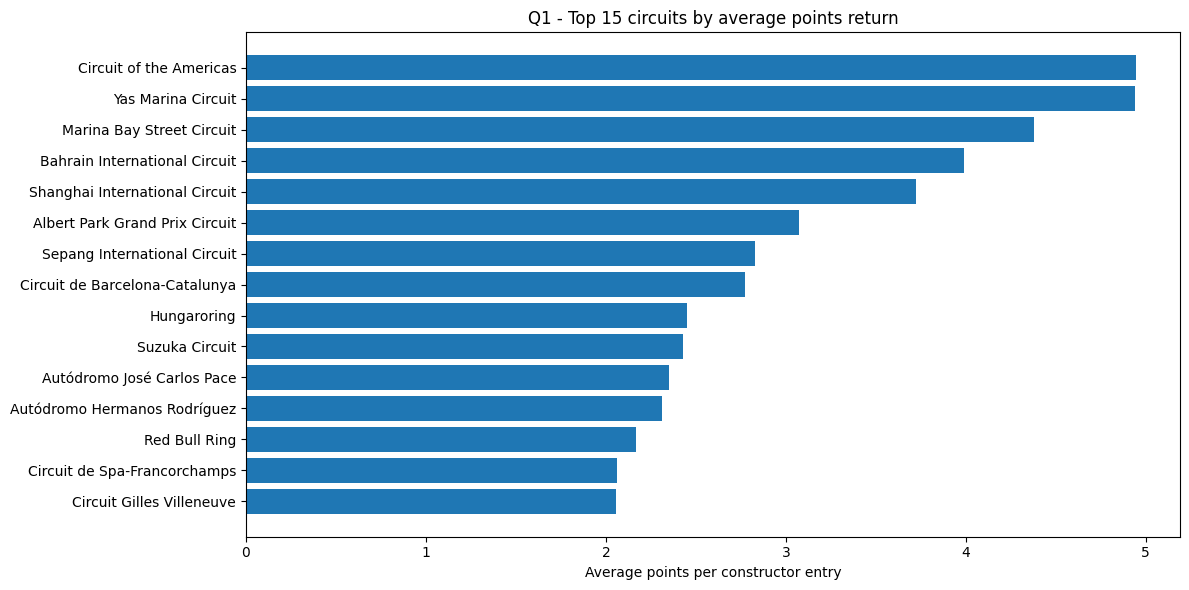

In [4]:
q1 = spark.sql("""
    SELECT circuit_name,
           COUNT(*)                AS entries,
           COUNT(DISTINCT year)    AS seasons,
           ROUND(AVG(points), 3)   AS avg_points_per_entry,
           ROUND(SUM(points), 1)   AS total_points
    FROM race_results
    GROUP BY circuit_name
    HAVING COUNT(*) >= 200
    ORDER BY avg_points_per_entry DESC
""")
q1.show(20, truncate=False)

q1_pd = q1.limit(15).toPandas()
plt.figure(figsize=(12, 6))
plt.barh(q1_pd["circuit_name"][::-1], q1_pd["avg_points_per_entry"][::-1], color="#1f77b4")
plt.xlabel("Average points per constructor entry")
plt.title("Q1 - Top 15 circuits by average points return")
plt.tight_layout()
plt.show()


### Q2 - Grid-to-finish translation

*How does starting grid position translate to final finish position, broken down
by circuit and era?* The first query traces average finishing position for each
grid slot across the three engine eras. The second uses a **window function
(`RANK()`)** to rank circuits by the grid-to-finish correlation - a low
correlation means grid matters less (more overtaking).

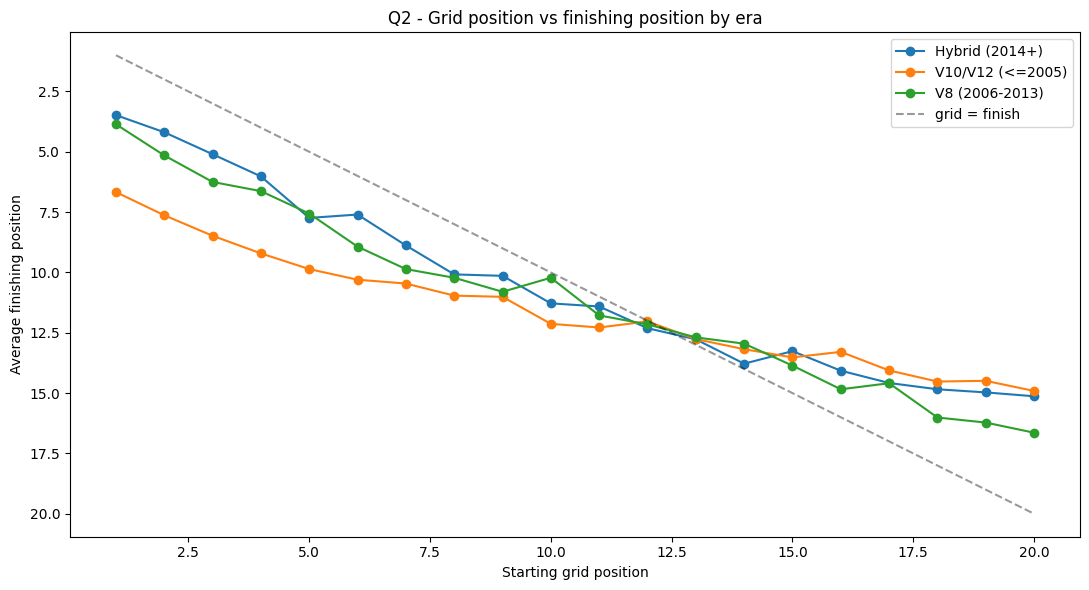

+-----------------------------+----------------+----+---------------+
|circuit_name                 |grid_finish_corr|n   |overtaking_rank|
+-----------------------------+----------------+----+---------------+
|Indianapolis Motor Speedway  |0.31            |537 |1              |
|Kyalami                      |0.313           |484 |2              |
|Brands Hatch                 |0.343           |346 |3              |
|Red Bull Ring                |0.364           |859 |4              |
|Watkins Glen                 |0.368           |459 |5              |
|Autódromo Juan y Oscar Gálvez|0.39            |435 |6              |
|Autodromo Nazionale di Monza |0.394           |1682|7              |
|Circuit Gilles Villeneuve    |0.398           |980 |8              |
|Nürburgring                  |0.405           |934 |9              |
|Autodromo Enzo e Dino Ferrari|0.409           |710 |10             |
+-----------------------------+----------------+----+---------------+
only showing top 10 

In [5]:
q2 = spark.sql("""
    SELECT era, grid,
           ROUND(AVG(positionOrder), 2) AS avg_finish,
           COUNT(*)                     AS n
    FROM race_results
    WHERE grid BETWEEN 1 AND 20 AND positionOrder IS NOT NULL
    GROUP BY era, grid
    ORDER BY era, grid
""")

q2_pd = q2.toPandas()
plt.figure(figsize=(11, 6))
for era, g in q2_pd.groupby("era"):
    g = g.sort_values("grid")
    plt.plot(g["grid"], g["avg_finish"], marker="o", label=era)
plt.plot([1, 20], [1, 20], "k--", alpha=0.4, label="grid = finish")
plt.xlabel("Starting grid position")
plt.ylabel("Average finishing position")
plt.title("Q2 - Grid position vs finishing position by era")
plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Circuit-level ranking by grid->finish correlation (window function RANK)
q2b = spark.sql("""
    WITH circ AS (
        SELECT circuit_name,
               CORR(grid, positionOrder) AS grid_finish_corr,
               COUNT(*)                  AS n
        FROM race_results
        WHERE grid BETWEEN 1 AND 30 AND positionOrder IS NOT NULL
        GROUP BY circuit_name
        HAVING COUNT(*) >= 300
    )
    SELECT circuit_name,
           ROUND(grid_finish_corr, 3) AS grid_finish_corr,
           n,
           RANK() OVER (ORDER BY grid_finish_corr ASC) AS overtaking_rank
    FROM circ
    ORDER BY grid_finish_corr ASC
""")
q2b.show(10, truncate=False)


### Q3 - Pit-stop strategy evolution

*How has average pit-stop count and duration evolved per decade, and which teams
pioneered fast (undercut-enabling) stops?* Reliable pit-stop timing exists from
2011 onward. The team ranking uses a **window function (`RANK()`)** to order
constructors by average stop duration in the early hybrid era (2011-2018) - the
fastest crews are best positioned to execute the undercut.

+------+------------------+----------------+-------+
|decade|avg_stops_per_race|avg_stop_seconds|entries|
+------+------------------+----------------+-------+
|2010s |2.08              |38.66           |3581   |
|2020s |1.97              |131.56          |1994   |
+------+------------------+----------------+-------+



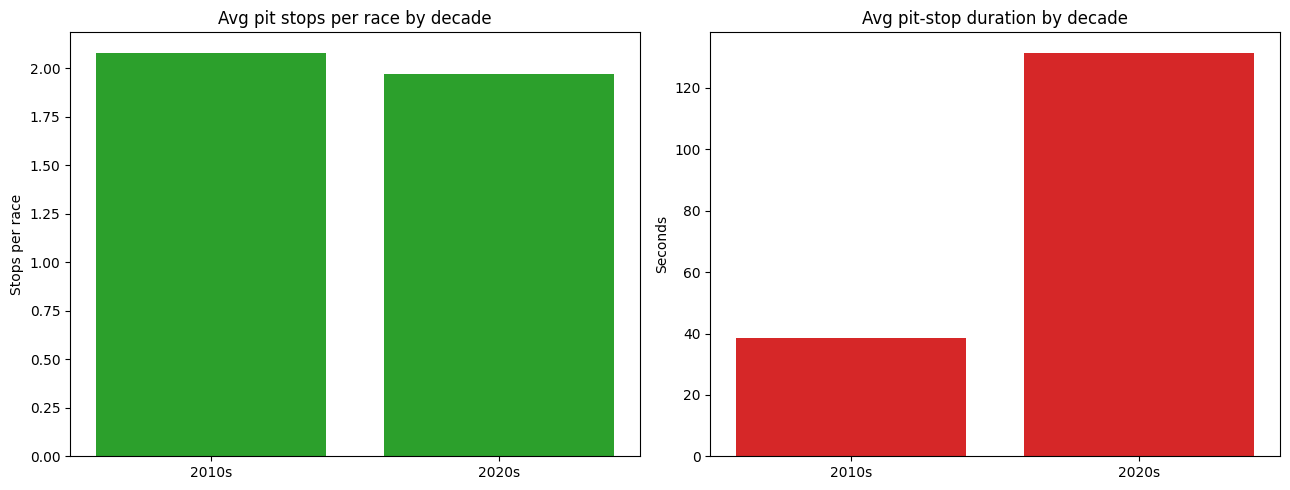

+----------------+----------+---------+-------+----------+
|constructor_name|avg_stop_s|avg_stops|entries|speed_rank|
+----------------+----------+---------+-------+----------+
|Lotus F1        |28.46     |2.14     |133    |1         |
|Caterham        |29.82     |2.43     |99     |2         |
|Marussia        |32.1      |2.24     |104    |3         |
|HRT             |33.06     |2.24     |67     |4         |
|Red Bull        |36.1      |2.18     |294    |5         |
|McLaren         |37.56     |2.16     |294    |6         |
|Ferrari         |39.44     |2.16     |296    |7         |
|Sauber          |40.36     |2.11     |295    |8         |
|Renault         |40.99     |2.06     |144    |9         |
|Toro Rosso      |41.08     |2.13     |291    |10        |
+----------------+----------+---------+-------+----------+
only showing top 10 rows


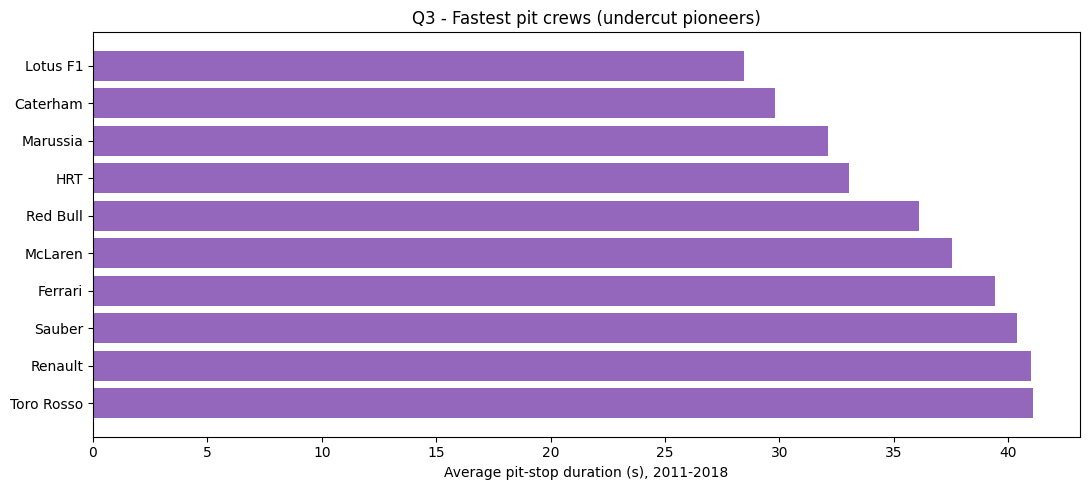

In [6]:
q3 = spark.sql("""
    SELECT decade,
           ROUND(AVG(pit_stop_count), 2)         AS avg_stops_per_race,
           ROUND(AVG(avg_pit_stop_ms) / 1000, 2) AS avg_stop_seconds,
           COUNT(*)                              AS entries
    FROM race_results
    WHERE pit_stop_count > 0 AND avg_pit_stop_ms > 0
    GROUP BY decade
    ORDER BY decade
""")
q3.show(truncate=False)

q3_pd = q3.toPandas()
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].bar(q3_pd["decade"], q3_pd["avg_stops_per_race"], color="#2ca02c")
ax[0].set_title("Avg pit stops per race by decade")
ax[0].set_ylabel("Stops per race")
ax[1].bar(q3_pd["decade"], q3_pd["avg_stop_seconds"], color="#d62728")
ax[1].set_title("Avg pit-stop duration by decade")
ax[1].set_ylabel("Seconds")
plt.tight_layout()
plt.show()

# Fastest-stop teams (undercut pioneers) - window function RANK
q3b = spark.sql("""
    WITH t AS (
        SELECT constructor_name,
               ROUND(AVG(avg_pit_stop_ms) / 1000, 2) AS avg_stop_s,
               ROUND(AVG(pit_stop_count), 2)         AS avg_stops,
               COUNT(*)                              AS entries
        FROM race_results
        WHERE year BETWEEN 2011 AND 2018 AND avg_pit_stop_ms > 0
        GROUP BY constructor_name
        HAVING COUNT(*) >= 50
    )
    SELECT constructor_name, avg_stop_s, avg_stops, entries,
           RANK() OVER (ORDER BY avg_stop_s ASC) AS speed_rank
    FROM t
    ORDER BY avg_stop_s ASC
""")
q3b.show(10, truncate=False)

q3b_pd = q3b.limit(10).toPandas()
plt.figure(figsize=(11, 5))
plt.barh(q3b_pd["constructor_name"][::-1], q3b_pd["avg_stop_s"][::-1], color="#9467bd")
plt.xlabel("Average pit-stop duration (s), 2011-2018")
plt.title("Q3 - Fastest pit crews (undercut pioneers)")
plt.tight_layout()
plt.show()


### Q4 - Constructor dominance windows

*Which constructors dominated consecutive seasons, and how long do dominance
cycles last?* The end-of-season constructors' champion is the team first at the
final round of each year. A **gaps-and-islands** pattern with the window function
**`ROW_NUMBER()`** groups consecutive championship years into dominance
streaks.

+----------------+------------+----------+------------------+
|constructor_name|streak_start|streak_end|consecutive_titles|
+----------------+------------+----------+------------------+
|Mercedes        |2014        |2021      |8                 |
|Ferrari         |1999        |2004      |6                 |
|McLaren         |1988        |1991      |4                 |
|Red Bull        |2010        |2013      |4                 |
|Ferrari         |1975        |1977      |3                 |
|Williams        |1992        |1994      |3                 |
|Cooper-Climax   |1959        |1960      |2                 |
|Brabham-Repco   |1966        |1967      |2                 |
|Team Lotus      |1972        |1973      |2                 |
|Williams        |1980        |1981      |2                 |
|Ferrari         |1982        |1983      |2                 |
|McLaren         |1984        |1985      |2                 |
|Williams        |1986        |1987      |2                 |
|William

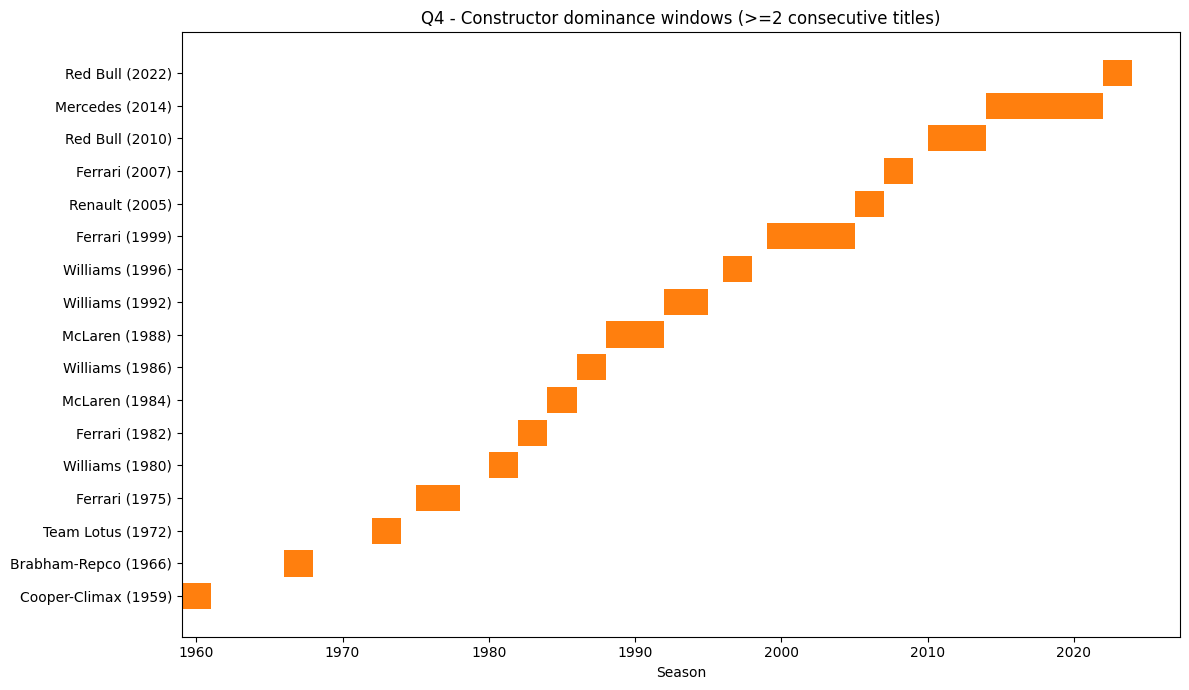

In [7]:
q4 = spark.sql("""
    WITH final_round AS (
        SELECT year, MAX(round) AS last_round FROM race_results GROUP BY year
    ),
    season_champ AS (
        SELECT r.year, r.constructor_name
        FROM race_results r
        JOIN final_round fr ON r.year = fr.year AND r.round = fr.last_round
        WHERE r.constructor_championship_position = 1
        GROUP BY r.year, r.constructor_name
    ),
    seq AS (
        SELECT year, constructor_name,
               year - ROW_NUMBER() OVER (
                          PARTITION BY constructor_name ORDER BY year) AS grp
        FROM season_champ
    )
    SELECT constructor_name,
           MIN(year) AS streak_start,
           MAX(year) AS streak_end,
           COUNT(*)  AS consecutive_titles
    FROM seq
    GROUP BY constructor_name, grp
    HAVING COUNT(*) >= 2
    ORDER BY consecutive_titles DESC, streak_start
""")
q4.show(20, truncate=False)

q4_pd = q4.toPandas().sort_values("streak_start")
plt.figure(figsize=(12, 7))
for _, row in q4_pd.iterrows():
    plt.barh(f'{row["constructor_name"]} ({row["streak_start"]})',
             row["streak_end"] - row["streak_start"] + 1,
             left=row["streak_start"], color="#ff7f0e")
plt.xlabel("Season")
plt.title("Q4 - Constructor dominance windows (>=2 consecutive titles)")
plt.tight_layout()
plt.show()


### Q5 - Home-circuit advantage

*Do drivers score significantly more points at their home Grand Prix?* Driver
nationality (a demonym) is mapped to the host country of each circuit to flag
home races. We compare overall home vs away average points, then list the drivers
with the largest home boost.

+----------+-------+----------+
|where_race|entries|avg_points|
+----------+-------+----------+
|away      |24238  |2.063     |
|home      |2521   |1.265     |
+----------+-------+----------+

+---------------------+--------+--------+----------+
|driver_name          |home_avg|away_avg|home_races|
+---------------------+--------+--------+----------+
|Lewis Hamilton       |17.42   |13.32   |19        |
|Gilles Villeneuve    |4.2     |1.37    |5         |
|Jim Clark            |6.0     |3.48    |8         |
|Alain Prost          |6.21    |3.78    |14        |
|Nigel Mansell        |4.71    |2.34    |14        |
|Emerson Fittipaldi   |4.13    |1.76    |8         |
|Lando Norris         |9.29    |7.31    |7         |
|Robert Manzon        |2.0     |0.25    |5         |
|Carlos Pace          |2.4     |0.68    |5         |
|Jean-Pierre Jabouille|1.8     |0.24    |5         |
|Felipe Massa         |5.79    |4.23    |14        |
|Fernando Alonso      |7.0     |5.68    |26        |
|Carlos Sain

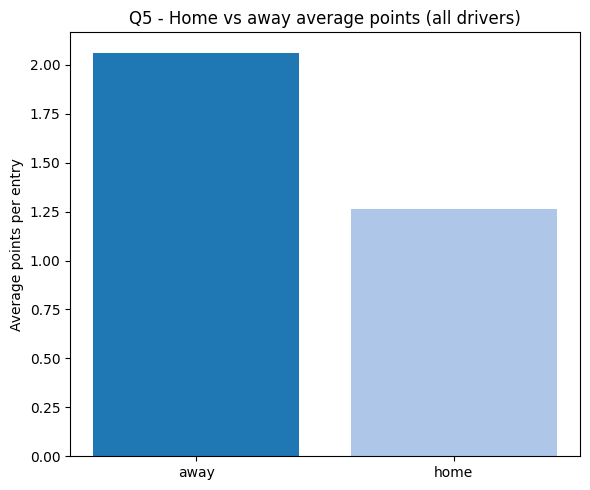

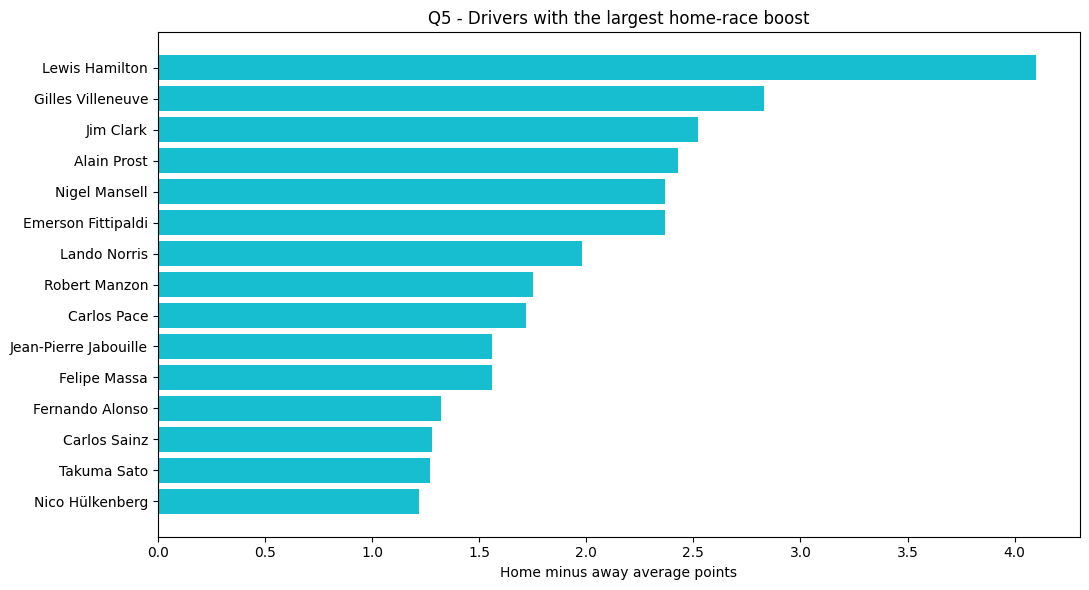

In [8]:
spark.sql("""
CREATE OR REPLACE TEMP VIEW nat_country AS
SELECT * FROM VALUES
 ('British','UK'), ('British','United Kingdom'),
 ('German','Germany'), ('Italian','Italy'), ('French','France'),
 ('Spanish','Spain'), ('Brazilian','Brazil'), ('Finnish','Finland'),
 ('Dutch','Netherlands'), ('Australian','Australia'), ('Austrian','Austria'),
 ('Canadian','Canada'), ('Mexican','Mexico'),
 ('American','USA'), ('American','United States'),
 ('Japanese','Japan'), ('Belgian','Belgium'), ('Argentine','Argentina'),
 ('Swiss','Switzerland'), ('Monegasque','Monaco'), ('Portuguese','Portugal'),
 ('Russian','Russia'), ('Hungarian','Hungary'), ('Swedish','Sweden'),
 ('Indian','India'), ('Thai','Thailand'), ('South African','South Africa')
 AS t(nationality, country)
""")

q5 = spark.sql("""
    WITH flagged AS (
        SELECT r.points,
               CASE WHEN nc.nationality IS NOT NULL THEN 'home' ELSE 'away' END AS where_race
        FROM race_results r
        LEFT JOIN nat_country nc
          ON r.driver_nationality = nc.nationality AND r.circuit_country = nc.country
    )
    SELECT where_race, COUNT(*) AS entries, ROUND(AVG(points), 3) AS avg_points
    FROM flagged
    GROUP BY where_race
""")
q5.show(truncate=False)

q5b = spark.sql("""
    WITH flagged AS (
        SELECT r.driver_name, r.points,
               CASE WHEN nc.nationality IS NOT NULL THEN 1 ELSE 0 END AS is_home
        FROM race_results r
        LEFT JOIN nat_country nc
          ON r.driver_nationality = nc.nationality AND r.circuit_country = nc.country
    )
    SELECT driver_name,
           ROUND(AVG(CASE WHEN is_home = 1 THEN points END), 2) AS home_avg,
           ROUND(AVG(CASE WHEN is_home = 0 THEN points END), 2) AS away_avg,
           SUM(is_home) AS home_races
    FROM flagged
    GROUP BY driver_name
    HAVING SUM(is_home) >= 5 AND (COUNT(*) - SUM(is_home)) >= 20
    ORDER BY (home_avg - away_avg) DESC
    LIMIT 15
""")
q5b.show(truncate=False)

q5_pd = q5.toPandas().set_index("where_race")
plt.figure(figsize=(6, 5))
plt.bar(q5_pd.index, q5_pd["avg_points"], color=["#1f77b4", "#aec7e8"])
plt.ylabel("Average points per entry")
plt.title("Q5 - Home vs away average points (all drivers)")
plt.tight_layout()
plt.show()

q5b_pd = q5b.toPandas()
q5b_pd["boost"] = q5b_pd["home_avg"] - q5b_pd["away_avg"]
plt.figure(figsize=(11, 6))
plt.barh(q5b_pd["driver_name"][::-1], q5b_pd["boost"][::-1], color="#17becf")
plt.xlabel("Home minus away average points")
plt.title("Q5 - Drivers with the largest home-race boost")
plt.tight_layout()
plt.show()


### Q6 - Wet vs dry performance

*Which constructors perform above their season average at historically wet
circuits (Spa, Interlagos, Suzuka)?* A **window function (`AVG() OVER`)** computes
each constructor's per-season average points; we then compare points scored at
the three wet circuits against that season baseline.

+----------------+-----------+--------------+-----------------+---------+
|constructor_name|wet_entries|avg_wet_points|avg_season_points|wet_boost|
+----------------+-----------+--------------+-----------------+---------+
|Alpine F1 Team  |22         |4.818         |2.734            |2.084    |
|Cooper-Climax   |20         |1.95          |1.099            |0.851    |
|Red Bull        |108        |10.634        |9.857            |0.777    |
|Force India     |64         |3.172         |2.609            |0.562    |
|Aston Martin    |22         |3.227         |2.842            |0.385    |
|Lotus-Climax    |27         |1.37          |1.072            |0.299    |
|Alfa Romeo      |36         |1.417         |1.121            |0.296    |
|Benetton        |86         |2.012         |1.742            |0.269    |
|Jordan          |88         |0.852         |0.593            |0.259    |
|Toro Rosso      |78         |1.09          |0.943            |0.147    |
|McLaren         |228        |4.145   

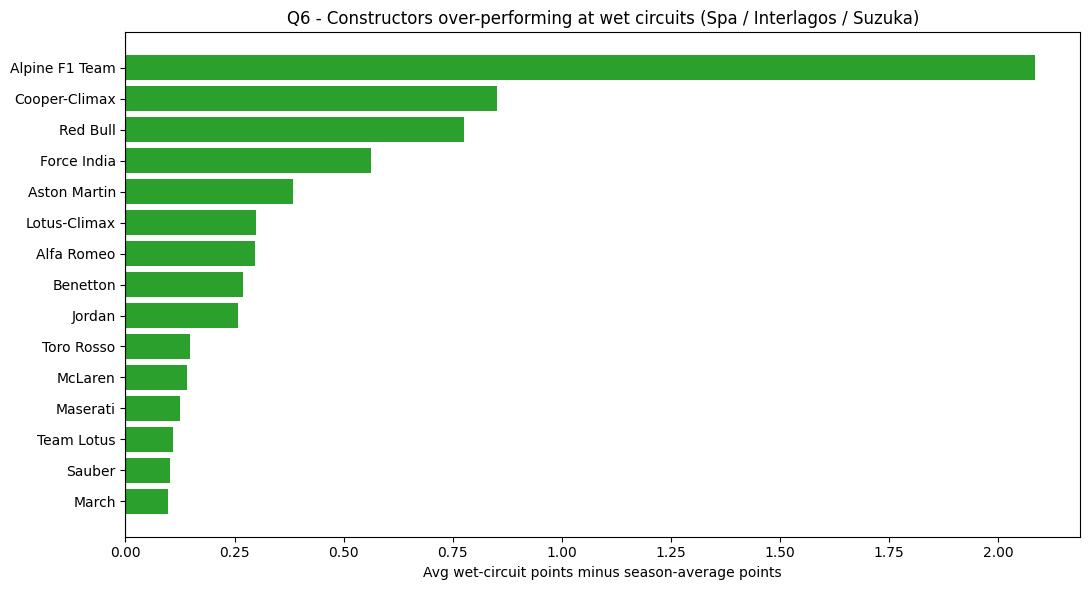

In [9]:
q6 = spark.sql("""
    WITH base AS (
        SELECT constructor_name, year, points, circuitRef,
               AVG(points) OVER (PARTITION BY constructor_name, year) AS season_avg_points,
               CASE WHEN circuitRef IN ('spa','interlagos','suzuka') THEN 1 ELSE 0 END AS wet
        FROM race_results
    )
    SELECT constructor_name,
           COUNT(*)                                        AS wet_entries,
           ROUND(AVG(points), 3)                           AS avg_wet_points,
           ROUND(AVG(season_avg_points), 3)               AS avg_season_points,
           ROUND(AVG(points) - AVG(season_avg_points), 3) AS wet_boost
    FROM base
    WHERE wet = 1
    GROUP BY constructor_name
    HAVING COUNT(*) >= 20
    ORDER BY wet_boost DESC
    LIMIT 20
""")
q6.show(truncate=False)

q6_pd = q6.limit(15).toPandas()
colors = ["#2ca02c" if v >= 0 else "#d62728" for v in q6_pd["wet_boost"]]
plt.figure(figsize=(11, 6))
plt.barh(q6_pd["constructor_name"][::-1], q6_pd["wet_boost"][::-1], color=colors[::-1])
plt.axvline(0, color="k", lw=0.8)
plt.xlabel("Avg wet-circuit points minus season-average points")
plt.title("Q6 - Constructors over-performing at wet circuits (Spa / Interlagos / Suzuka)")
plt.tight_layout()
plt.show()


### Q7 - Fastest lap trends

*How has the fastest lap time per circuit evolved across the hybrid era vs the
V8 / V10 eras?* The fastest lap of each race is taken as the quickest single lap
in the silver `lap_times` table (reliably populated from 1996 onward). We track
the best lap per season at five long-standing circuits - Monza, Silverstone, Spa,
Monaco and Suzuka - and summarise the average per engine era.

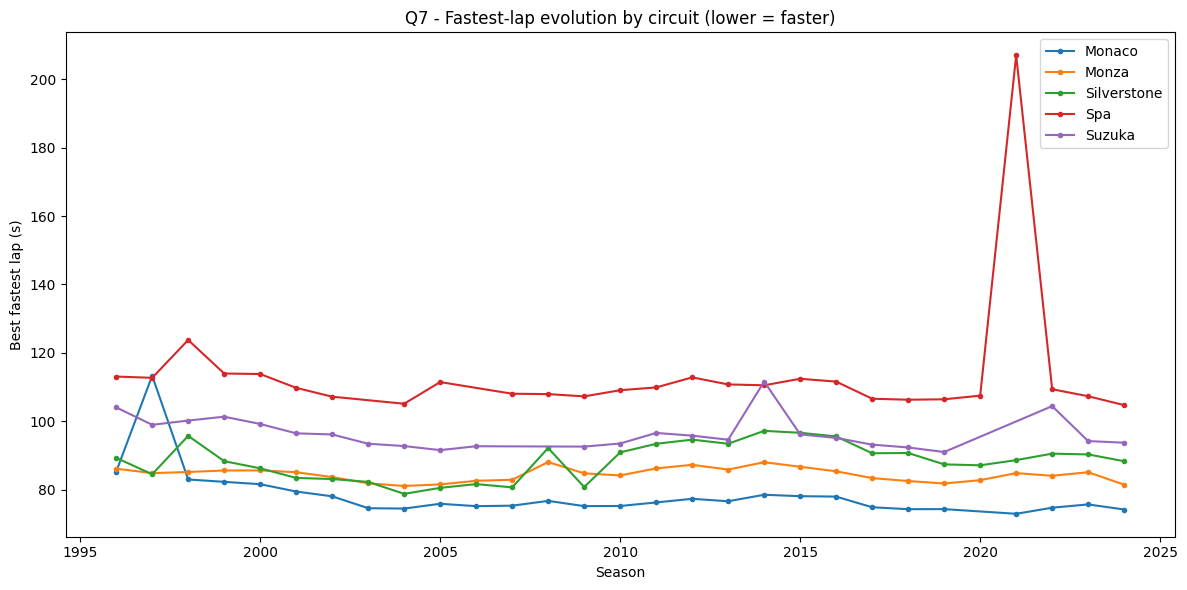

+-----------+----------------+--------------+
|circuit    |era             |avg_best_lap_s|
+-----------+----------------+--------------+
|Monaco     |Hybrid (2014+)  |75.526        |
|Monaco     |V10/V12 (<=2005)|82.757        |
|Monaco     |V8 (2006-2013)  |75.946        |
|Monza      |Hybrid (2014+)  |84.159        |
|Monza      |V10/V12 (<=2005)|84.034        |
|Monza      |V8 (2006-2013)  |85.204        |
|Silverstone|Hybrid (2014+)  |90.939        |
|Silverstone|V10/V12 (<=2005)|85.196        |
|Silverstone|V8 (2006-2013)  |88.425        |
|Spa        |Hybrid (2014+)  |117.245       |
|Spa        |V10/V12 (<=2005)|112.309       |
|Spa        |V8 (2006-2013)  |109.394       |
|Suzuka     |Hybrid (2014+)  |96.845        |
|Suzuka     |V10/V12 (<=2005)|97.394        |
|Suzuka     |V8 (2006-2013)  |94.275        |
+-----------+----------------+--------------+



In [14]:
# Fastest lap sourced from silver lap_times (best actual lap per race), which is
# reliably populated from 1996 onward. Circuits matched by name to avoid any
# dependence on exact circuitRef spelling.
silver["lap_times"].createOrReplaceTempView("lap_times")

spark.sql("""
CREATE OR REPLACE TEMP VIEW best_laps AS
WITH race_circ AS (
    SELECT DISTINCT raceId, circuitId, year FROM frr
),
best AS (
    SELECT raceId, MIN(lap_time_ms) AS best_lap_ms
    FROM lap_times
    WHERE lap_time_ms > 0
    GROUP BY raceId
)
SELECT cir.circuit_name,
       CASE
           WHEN cir.circuit_name LIKE '%Monza%'       THEN 'Monza'
           WHEN cir.circuit_name LIKE '%Silverstone%' THEN 'Silverstone'
           WHEN cir.circuit_name LIKE '%Spa%'         THEN 'Spa'
           WHEN cir.circuit_name LIKE '%Monaco%'      THEN 'Monaco'
           WHEN cir.circuit_name LIKE '%Suzuka%'      THEN 'Suzuka'
       END AS circuit,
       rc.year,
       CASE WHEN rc.year <= 2005 THEN 'V10/V12 (<=2005)'
            WHEN rc.year <= 2013 THEN 'V8 (2006-2013)'
            ELSE 'Hybrid (2014+)' END AS era,
       b.best_lap_ms
FROM best b
JOIN race_circ rc   ON b.raceId   = rc.raceId
JOIN dim_circuit cir ON rc.circuitId = cir.circuitId
WHERE cir.circuit_name LIKE '%Monza%' OR cir.circuit_name LIKE '%Silverstone%'
   OR cir.circuit_name LIKE '%Spa%'   OR cir.circuit_name LIKE '%Monaco%'
   OR cir.circuit_name LIKE '%Suzuka%'
""")

q7 = spark.sql("""
    SELECT circuit, year, era,
           ROUND(MIN(best_lap_ms) / 1000, 3) AS best_lap_s
    FROM best_laps
    GROUP BY circuit, year, era
    ORDER BY circuit, year
""")

q7_pd = q7.toPandas()
plt.figure(figsize=(12, 6))
for ref, g in q7_pd.groupby("circuit"):
    g = g.sort_values("year")
    plt.plot(g["year"], g["best_lap_s"], marker="o", ms=3, label=ref)
plt.xlabel("Season")
plt.ylabel("Best fastest lap (s)")
plt.title("Q7 - Fastest-lap evolution by circuit (lower = faster)")
plt.legend()
plt.tight_layout()
plt.show()

q7b = spark.sql("""
    SELECT circuit, era, ROUND(AVG(best_lap_ms) / 1000, 3) AS avg_best_lap_s
    FROM best_laps
    GROUP BY circuit, era
    ORDER BY circuit, era
""")
q7b.show(30, truncate=False)


### Q8 - Championship decided by reliability

*In how many seasons did mechanical failures (DNFs from `status`) cost the
eventual runner-up the title?* For each season we take the final top-two drivers
and count the runner-up's mechanical DNFs. Rather than assuming each retirement
would have been a win (an unrealistic upper bound, and one that ignores how the
points system changed over time), we estimate the points the runner-up *would
plausibly have scored* in those races as their **own average points per finished
race that season**. The recoverable total is therefore
`mech_dnf * avg_points_when_finishing`, and a season is flagged only when that
estimate is at least as large as the title gap. A window function
(`ROW_NUMBER()`) picks the final standings row per season.

+----+------------------+---------+-----------------+----------+---------+------------------+---------------------+-------------------+
|year|champion          |champ_pts|runner_up        |runner_pts|title_gap|runnerup_mech_dnfs|avg_pts_when_finished|est_recoverable_pts|
+----+------------------+---------+-----------------+----------+---------+------------------+---------------------+-------------------+
|1950|Nino Farina       |30.0     |Juan Fangio      |27.0      |3.0      |4                 |8.67                 |34.7               |
|1951|Juan Fangio       |31.0     |Alberto Ascari   |25.0      |6.0      |2                 |4.67                 |9.3                |
|1953|Alberto Ascari    |34.5     |Juan Fangio      |28.0      |6.5      |4                 |4.92                 |19.7               |
|1956|Juan Fangio       |30.0     |Stirling Moss    |27.0      |3.0      |4                 |5.4                  |21.6               |
|1958|Mike Hawthorn     |42.0     |Stirling Moss

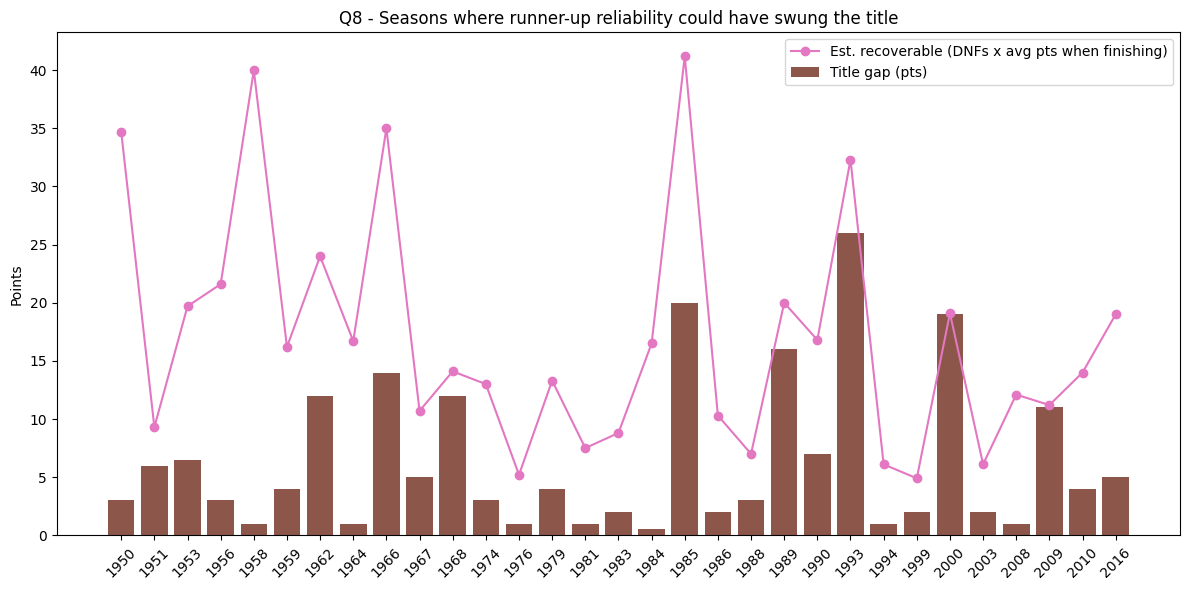

In [13]:
MECH = ("(engine|gearbox|transmission|clutch|hydraul|electr|radiator|suspension|"
        "brake|overheat|mechanical|puncture|throttle|steering|exhaust|oil|pneumatic|"
        "wing|fire|vibration|ignit|battery|crank|alternat|distributor|turbo|driveshaft|"
        "spark|axle|power unit|ers|fuel|water|cool|wheel|differential|halfshaft|pump|"
        "magnet|drivetrain|gear|chassis)")

q8 = spark.sql(f"""
    WITH final_round AS (
        SELECT year, MAX(round) AS last_round FROM race_results GROUP BY year
    ),
    standings AS (
        SELECT r.year, r.driver_name,
               r.driver_championship_position AS pos,
               r.driver_championship_points   AS pts,
               ROW_NUMBER() OVER (
                   PARTITION BY r.year, r.driver_championship_position
                   ORDER BY r.round DESC) AS rn
        FROM race_results r
        JOIN final_round fr ON r.year = fr.year AND r.round = fr.last_round
        WHERE r.driver_championship_position IN (1, 2)
    ),
    top2 AS (SELECT year, driver_name, pos, pts FROM standings WHERE rn = 1),
    champ  AS (SELECT year, driver_name AS champion,  pts AS champ_pts  FROM top2 WHERE pos = 1),
    runner AS (SELECT year, driver_name AS runner_up, pts AS runner_pts FROM top2 WHERE pos = 2),
    -- per driver-season: mechanical DNFs and average points in races they FINISHED
    driver_year AS (
        SELECT year, driver_name,
               SUM(CASE WHEN LOWER(status) RLIKE '{MECH}' THEN 1 ELSE 0 END) AS mech_dnf,
               -- expected points per race when NOT sidelined by a mechanical failure
               AVG(CASE WHEN LOWER(status) RLIKE '{MECH}' THEN NULL ELSE points END) AS avg_pts_finished
        FROM race_results
        GROUP BY year, driver_name
    )
    SELECT c.year, c.champion, c.champ_pts,
           ru.runner_up, ru.runner_pts,
           (c.champ_pts - ru.runner_pts)                       AS title_gap,
           dy.mech_dnf                                         AS runnerup_mech_dnfs,
           ROUND(dy.avg_pts_finished, 2)                       AS avg_pts_when_finished,
           ROUND(dy.mech_dnf * dy.avg_pts_finished, 1)         AS est_recoverable_pts
    FROM champ c
    JOIN runner ru ON c.year = ru.year
    JOIN driver_year dy ON ru.year = dy.year AND ru.runner_up = dy.driver_name
    WHERE dy.mech_dnf >= 1
      AND (c.champ_pts - ru.runner_pts) <= dy.mech_dnf * dy.avg_pts_finished
    ORDER BY c.year
""")
q8.show(50, truncate=False)
print("Seasons where runner-up reliability could plausibly have cost the title:",
      q8.count())

q8_pd = q8.toPandas()
if len(q8_pd):
    x = list(range(len(q8_pd)))
    plt.figure(figsize=(12, 6))
    plt.bar(x, q8_pd["title_gap"], color="#8c564b", label="Title gap (pts)")
    plt.plot(x, q8_pd["est_recoverable_pts"], "o-", color="#e377c2",
             label="Est. recoverable (DNFs x avg pts when finishing)")
    plt.xticks(x, q8_pd["year"], rotation=45)
    plt.ylabel("Points")
    plt.title("Q8 - Seasons where runner-up reliability could have swung the title")
    plt.legend()
    plt.tight_layout()
    plt.show()

## F1 driver-movement flow chart (2020–2024)

PySpark pipeline + Graphviz rendering.

**Layout:** years down the left, the 10 teams as colored columns on top, each
driver shown by a 3-letter code plus the season **teammate qualifying
head-to-head** (`wins-losses`, the *out-qualify score*). Solid lines = season-
to-season continuity; **dotted lines = a driver returning after a break**.

**Note on teams — RB is not Red Bull.** `Red Bull` is Red Bull Racing; `RB` is
the sister team (Toro Rosso → AlphaTauri → RB). Renamed constructors are
collapsed to one canonical column so there are exactly 10:
`Renault→Alpine`, `Racing Point→Aston Martin`, `AlphaTauri→RB`,
`Alfa Romeo→Sauber`. That is why the RB column is populated for every season
(it absorbs the AlphaTauri entries).

In [ ]:
START, END = 2020, 2024

drivers = spark.read.parquet(f"{GOLD_PATH}/dim_driver")
cons    = spark.read.parquet(f"{GOLD_PATH}/dim_constructor")
facts   = (spark.read.parquet(f"{GOLD_PATH}/fact_race_result")
                .filter((F.col("year") >= START) & (F.col("year") <= END)))

### Combined: `describe_cluster(...)` with output flags

Toggle each output: `show_table`, `show_bar`, `show_heatmap`. Pick which metric the bar (`bar_metric`) and heatmap (`heatmap_metric`) use.

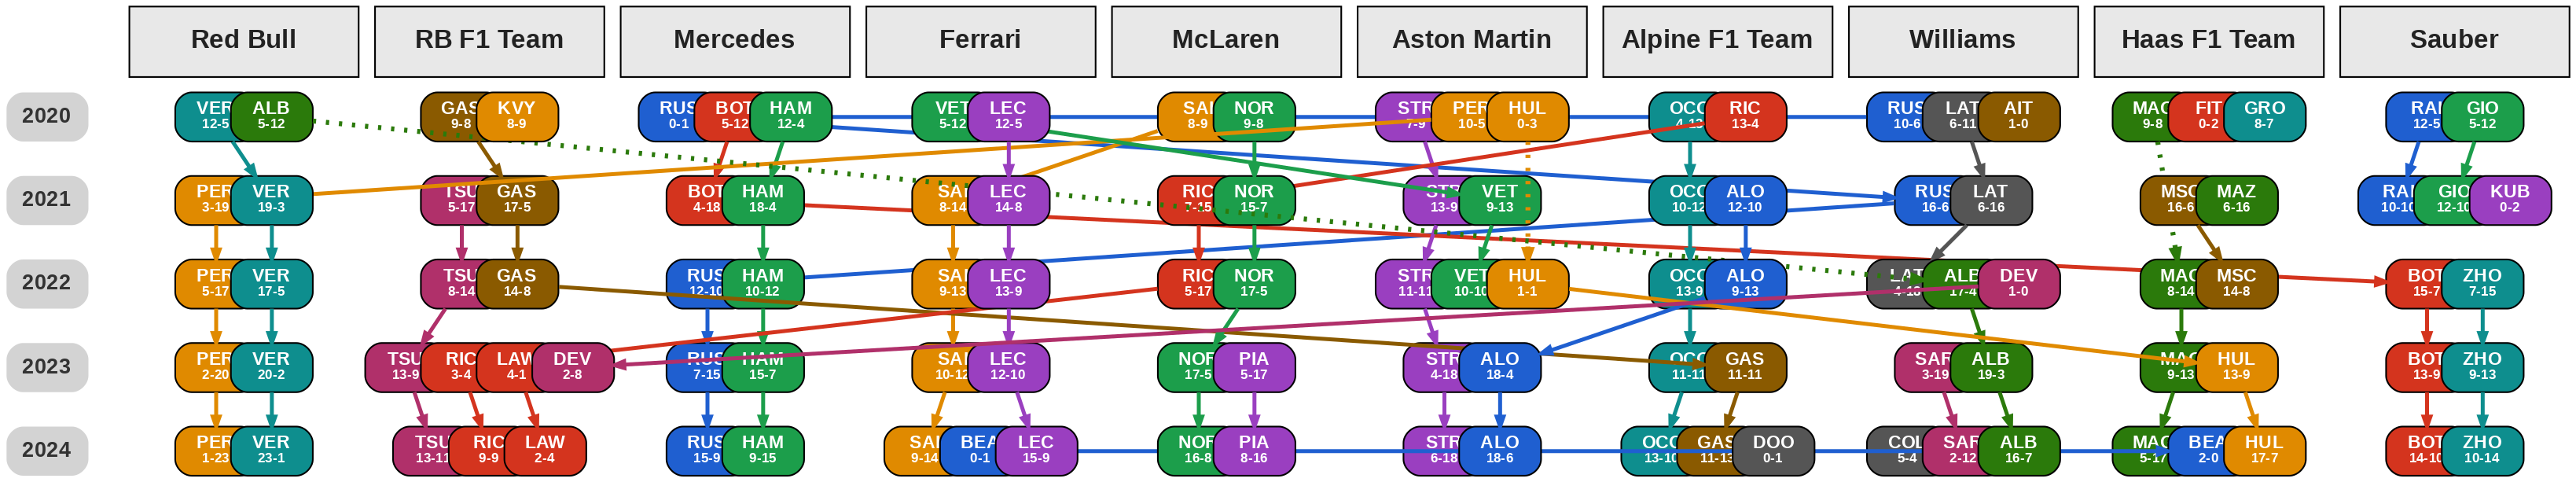

,team,drivers,driver_seasons,starts,wins,podiums,points,win_pct,podium_pct,points_per_start,avg_finish,avg_grid,quali_h2h,race_h2h
0,Red Bull,3,10,214,60,112,2948.5,28.04,52.34,13.778,5.56,5.16,107-107,107-107
1,Mercedes,3,11,214,27,87,2479.5,12.62,40.65,11.586,5.85,5.10,107-107,107-107
2,Ferrari,4,11,214,10,59,1930.5,4.67,27.57,9.021,7.31,6.10,107-107,107-107
3,McLaren,4,10,214,7,38,1501.0,3.27,17.76,7.014,8.16,7.91,107-107,107-107
4,Aston Martin,5,12,214,1,13,702.0,0.47,6.07,3.280,10.85,11.56,107-107,107-107
5,Alpine F1 Team,5,11,214,1,9,679.0,0.47,4.21,3.173,10.86,11.04,107-107,107-107
6,RB F1 Team,6,13,214,1,2,346.0,0.47,0.93,1.617,12.58,12.16,107-107,107-107
7,Haas F1 Team,7,12,214,0,0,96.0,0.00,0.00,0.449,14.90,15.06,106-106,107-107
8,Sauber,5,11,214,0,0,94.0,0.00,0.00,0.439,14.02,15.23,107-107,107-107
9,Williams,7,13,213,0,1,74.0,0.00,0.47,0.347,14.90,15.62,106-106,106-106


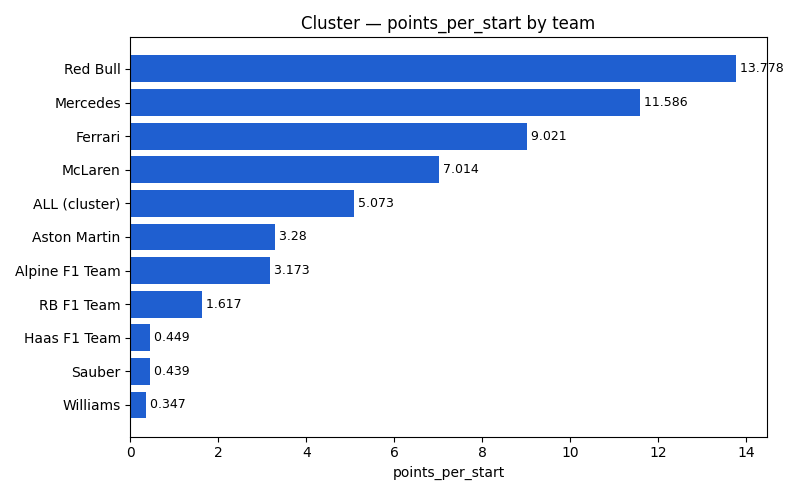

In [ ]:
# default: flow chart only
#cluster = ["HAM", "BOT", "VER", "PER", "LEC", "SAI", "NOR", "RIC"]
teams=['Red Bull', 'RB F1 Team', 'Mercedes', 'Ferrari', 'McLaren', 'Aston Martin', 'Alpine F1 Team', 'Williams', 'Haas F1 Team', 'Sauber']
yrs = list(range(2020, 2025))
describe_cluster(spark, GOLD_PATH, years=yrs, teams=teams, show_table=True, show_bar=True)

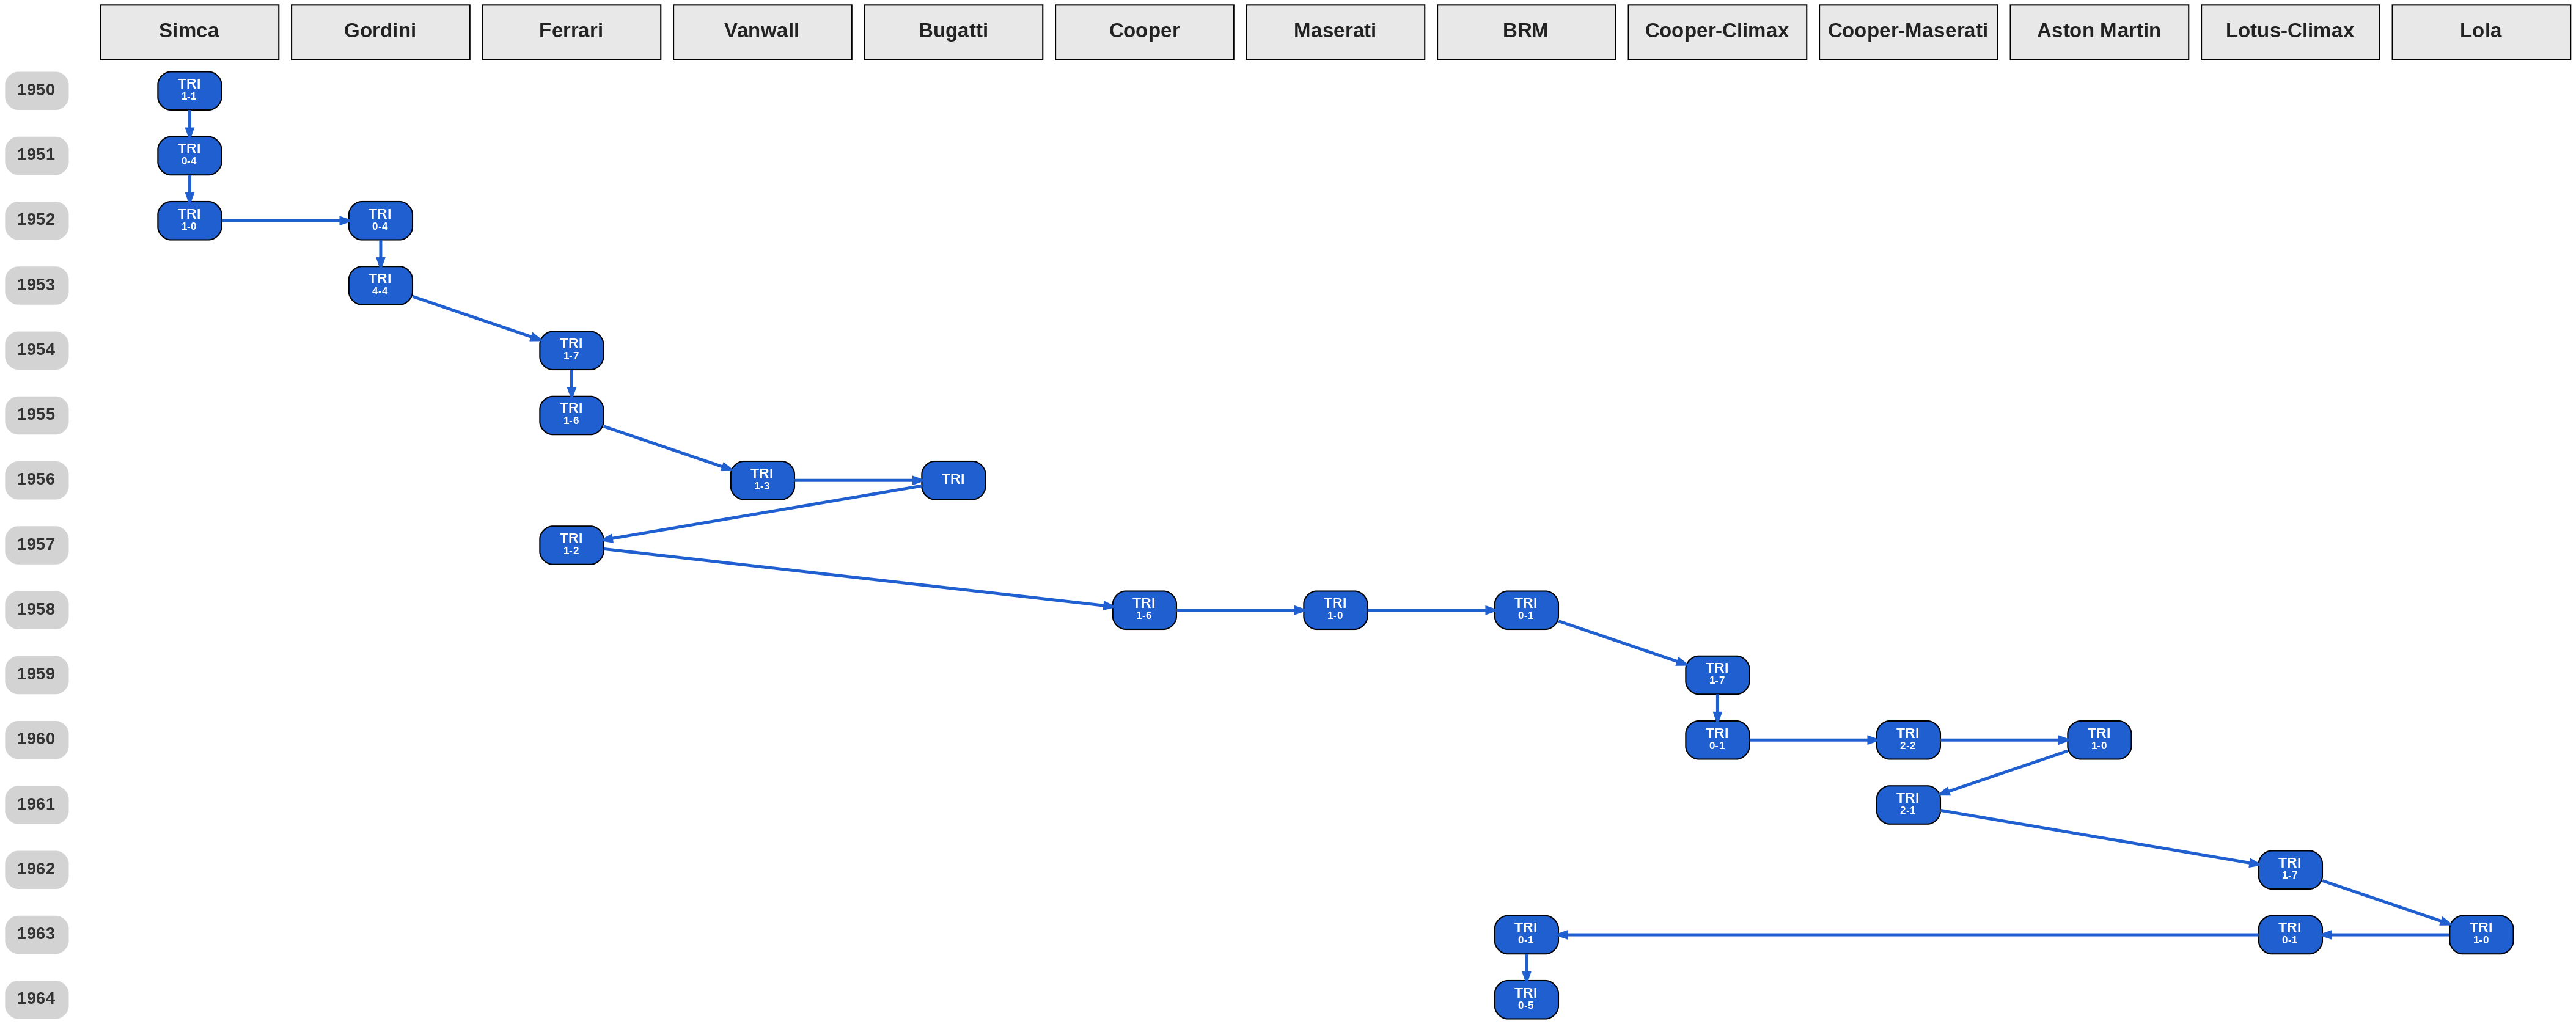

In [ ]:
cluster = ["Maurice Trintignant"]
describe_cluster(spark, GOLD_PATH, cluster)

### Cluster statistics

A *cluster* is a set of drivers (given by 3-letter abbreviations or full names or driver ids). These functions summarise the cluster across the teams its members raced for, with totals **and** per-start rates so teams of different size/era are comparable. Omit `abbrs` to include every driver for the chosen `teams`/`years`.

,team,drivers,driver_seasons,starts,wins,podiums,points,win_pct,podium_pct,points_per_start,avg_finish,avg_grid,quali_h2h,race_h2h
0,Red Bull,1,7,149,60,101,2491.5,40.27,67.79,16.721,4.28,3.64,132-17,123-26
1,Mercedes,2,11,229,50,130,3225.5,21.83,56.77,14.085,4.76,4.01,110-119,115-114
2,Sauber,1,3,68,0,0,57.0,0.00,0.00,0.838,14.01,13.63,51-17,42-26
3,ALL (cluster),3,21,446,110,231,5774.0,24.66,51.80,12.946,6.01,5.35,293-153,280-166


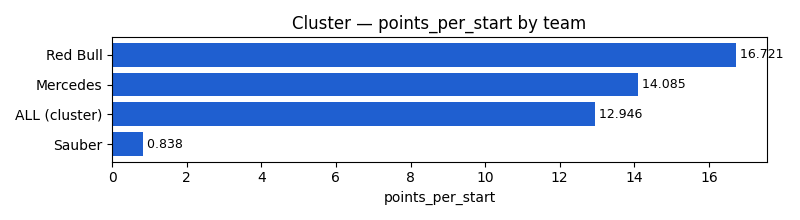

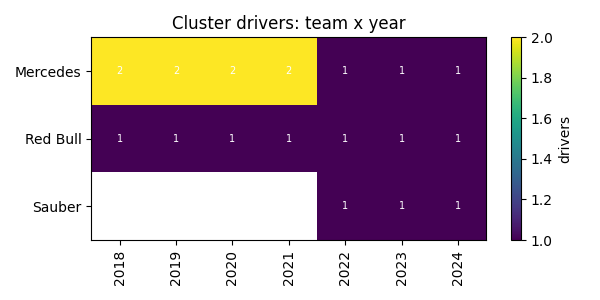

'cluster_heatmap.png'

In [17]:
# Example: describe a cluster given by driver abbreviations
cluster = ["Lewis Hamilton", "Valtteri Bottas", "Max Verstappen"]
yrs = list(range(2018, 2025))

summary = cluster_team_summary(spark, GOLD_PATH, cluster, years=yrs)
display(summary)                                   # comparable team table

cluster_bar(summary, metric="points_per_start")    # compare teams on one rate
cluster_heatmap(spark, GOLD_PATH, cluster, years=yrs, metric="drivers")
